# Model Evaluation & Validation

For the past 13 lessons, we have focused on *building* algorithms—using calculus, geometry, and probability to bend mathematics around our data. But building a model is only half of a Data Scientist's job. 

The other half is **proving that the model actually works**. 

If you train a model and ask it to predict the exact data it just memorized, it will look like a genius. But when you deploy it into production to predict the future, it will fail catastrophically. In this lesson, we transition from building to auditing. We will explore the rigorous mathematical frameworks used to test algorithms against the unknown.

The golden rule of Machine Learning is: **Training error is an optimistically biased estimate of true generalization error.** To find the truth, we must mathematically separate our data into distinct sets, forcing the algorithm to take "blind" exams.

Let's set up our Python environment to simulate enterprise model validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Model Auditing & Validation Environment Ready.")

✅ Model Auditing & Validation Environment Ready.


# 1. The Holdout Method (Train / Test Split)

The simplest way to evaluate a model is the **Holdout Method**. We take our total dataset ($D$) and mathematically partition it into two mutually exclusive sets:
* **Training Set ($D_{train}$)**: Usually 70-80% of the data. The algorithm uses this to calculate gradients, adjust weights, and learn the function $f(X)$.
* **Test Set ($D_{test}$)**: Usually 20-30% of the data. This data is locked in a vault. The model never sees it during training. We use it once at the very end to calculate the true irreducible error.

Mathematically, this split guarantees:
$$D = D_{train} \cup D_{test} \quad \text{and} \quad D_{train} \cap D_{test} = \emptyset$$

In [2]:
# 1. Simulate a corporate dataset (e.g., 1000 Customer Profiles)
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Perform the Train/Test Split
# test_size=0.2 means 20% goes to the vault.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Dataset: {X.shape[0]} rows")
print(f"Training Set : {X_train.shape[0]} rows (Used for Learning)")
print(f"Test Set     : {X_test.shape[0]} rows (Locked in the Vault)")

# 3. Train on Train, Evaluate on Test
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"\n🚨 Training Accuracy: {train_acc * 100:.1f}% (Optimistic Lie)")
print(f"🚨 Test Accuracy    : {test_acc * 100:.1f}% (The Truth)")

Total Dataset: 1000 rows
Training Set : 800 rows (Used for Learning)
Test Set     : 200 rows (Locked in the Vault)

🚨 Training Accuracy: 93.9% (Optimistic Lie)
🚨 Test Accuracy    : 87.5% (The Truth)


*(Insight: Notice the drop in accuracy! The model scored 94.5% on the test it studied for, but only 86.5% on the final exam. The 86.5% is what you actually report to the CEO.)*

# 2. The Three-Way Split (Train / Validation / Test)

There is a fatal flaw in the simple Train/Test split. What happens if you run your model, get 86.5% on the Test Set, and decide you want to tweak the `max_depth` hyperparameter to get a better score? 

If you tweak the model, re-test it on the Test Set, tweak it again, and re-test it again, **you are leaking information from the Test Set into the model.** The human (you) is acting as a secondary optimization engine, manually fitting the hyperparameters to memorize the Test Set!

To prevent this, enterprise ML uses a **Three-Way Split**:
1.  **Train Set (60%)**: Used by the algorithm to learn weights ($\theta$).
2.  **Validation Set (20%)**: Used by the Data Scientist to tune hyperparameters (e.g., depth, learning rate).
3.  **Test Set (20%)**: Touched strictly *once* before deployment to calculate final performance. 

# 3. K-Fold Cross-Validation

The Holdout Method has a second flaw: **Variance of the Split**. What if, by pure geographic luck, all the hardest, weirdest outliers ended up in your Test Set? Your model would look terrible. What if all the easiest data ended up in the Test Set? Your model would look amazing, but fail in production.

To solve this, we use **$K$-Fold Cross-Validation**. 
Instead of splitting the data once, we chop the dataset into $K$ equal-sized blocks (folds). 
We train the model on $K-1$ blocks and test it on the 1 remaining block. We repeat this process $K$ times, rotating the test block each time, until every single block has served as the Test Set exactly once.

The final mathematical performance is the average of all $K$ tests:
$$CV_{(K)} = \frac{1}{K} \sum_{i=1}^{K} \text{Score}_i$$

Let's visualize this rotation in code.

--- 5-Fold Cross-Validation Scores ---
Fold 1: 87.5%
Fold 2: 86.0%
Fold 3: 93.5%
Fold 4: 89.0%
Fold 5: 90.5%

🚨 Final CV Accuracy: 89.3% ± 2.6%


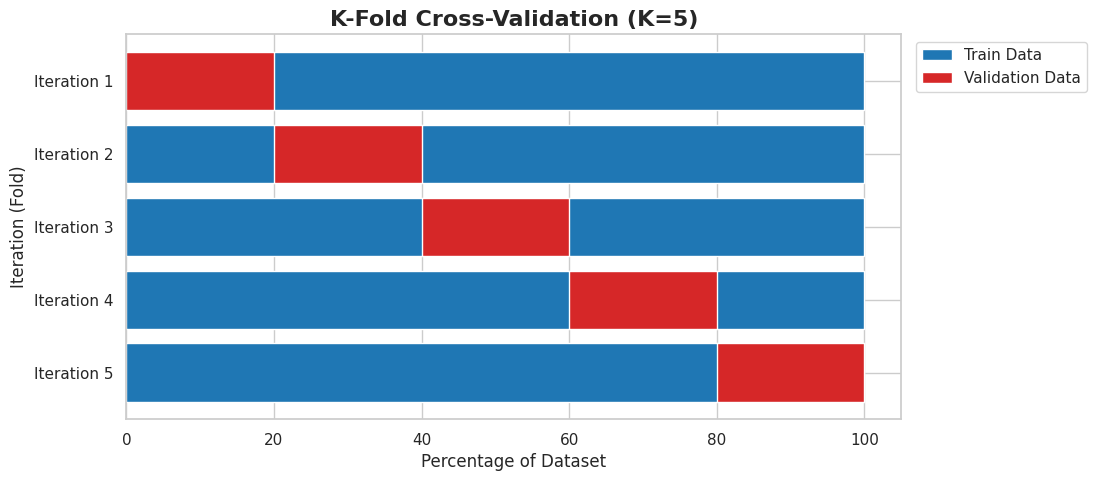

In [3]:
# 1. Setup K-Fold (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run Cross-Validation
# This function automatically handles the splitting, training, and testing loop!
cv_scores = cross_val_score(clf, X, y, cv=kf, scoring='accuracy')

print("--- 5-Fold Cross-Validation Scores ---")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score * 100:.1f}%")

print(f"\n🚨 Final CV Accuracy: {cv_scores.mean() * 100:.1f}% ± {cv_scores.std() * 100:.1f}%")

# 3. Matplotlib Visualization of K-Fold Logic
plt.figure(figsize=(10, 5))
for i in range(5):
    # Create the train (blue) and test (red) blocks for each iteration
    plt.barh(i, 100, color='#1f77b4', edgecolor='white', label='Train Data' if i == 0 else "")
    plt.barh(i, 20, left=i*20, color='#d62728', edgecolor='white', label='Validation Data' if i == 0 else "")

plt.title("K-Fold Cross-Validation (K=5)", fontsize=16, fontweight='bold')
plt.xlabel("Percentage of Dataset")
plt.ylabel("Iteration (Fold)")
plt.yticks(range(5), [f"Iteration {i+1}" for i in range(5)])
plt.gca().invert_yaxis()
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

*(Insight: Look at the visual. Every single row of data in your 100% dataset gets used for training 4 times, and gets tested exactly 1 time. The variance of a "lucky" split is completely mathematically destroyed!)*

# 4. Stratification and Temporal Constraints

Not all data can be randomly shuffled. You must respect the underlying physics and probability distributions of your problem.

### Stratification (Class Imbalance)
If you are predicting Credit Card Fraud, maybe only 1% of your dataset is actual fraud ($y=1$). If you randomly slice your data into 5 folds, it is mathematically possible that Fold 3 gets 0% fraud data. The model will crash. 
We must use **Stratified K-Fold** (`StratifiedKFold`). This algorithm mathematically guarantees that every single fold perfectly maintains the exact prior probability distribution $P(y)$ of the original dataset.

### Temporal Splits (Time Series Leakage)
If your dataset is organized by time (e.g., Stock Prices from Jan to Dec), you **cannot** use random K-Fold or `train_test_split`. If you randomly shuffle the data, you might train the model on data from November and test it on data from March. You just gave the model the ability to look into the future!
For time series, you must use a sliding window (e.g., Train on Jan-Mar, Test on Apr. Then Train on Jan-Apr, Test on May).

## Real-World Use Case or Analogy:
Think of Model Validation like **Training an Athlete for the Olympics**:

* **The Training Set (Practice)**: The athlete runs sprints on their home track every day. If you only measure their speed here (Training Accuracy), they look like a world-record holder because they have memorized every crack in the pavement.
* **The Validation Set (The Scrimmage)**: Once a month, the coach takes them to a neighboring town for a scrimmage. The coach watches their performance and tweaks their diet and sleeping schedule (Hyperparameter Tuning). 
* **The Test Set (The Olympics)**: The final race in Paris. The athlete has never seen this track. The coach is not allowed to tweak their diet during the race. This is the only score that matters.
* **Data Leakage**: If the coach secretly sneaks the athlete into the Olympic stadium to practice at 2:00 AM every night before the race, that is Data Leakage. The final Olympic medal is fraudulent because the athlete studied the specific exam.

---